# Alfido Tech — Internship Conversion Funnel Analysis
**Business Question:** *What are the key drivers of internship offer acceptance, and where in the recruitment funnel does Alfido Tech lose the most candidates?*


In [1]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

# ── Auto-locate project root so paths work from any launch directory ──────────
def find_project_root():
    for p in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
        if (p / 'data' / 'alfido_internship_funnel.csv').exists():
            return p
    return pathlib.Path.cwd()

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
DATA_PATH   = str(PROJECT_ROOT / 'data'   / 'alfido_internship_funnel.csv')
CHARTS_DIR  = str(PROJECT_ROOT / 'charts')

print(f"Project root : {PROJECT_ROOT}")
print(f"Data file    : {DATA_PATH}")
print("Libraries loaded ✓")


Project root : /content
Data file    : /content/data/alfido_internship_funnel.csv
Libraries loaded ✓


## 1. Data Loading & Overview

In [3]:
df = pd.read_csv('alfido_internship_funnel.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)


Dataset shape: (500, 14)
Columns: ['applicant_id', 'application_month', 'department', 'source', 'education', 'cgpa', 'prior_experience_months', 'screened', 'interview_invited', 'interview_attended', 'task_assigned', 'offer_made', 'offer_accepted', 'drop_reason']


,applicant_id,application_month,department,source,education,cgpa,prior_experience_months,screened,interview_invited,interview_attended,task_assigned,offer_made,offer_accepted,drop_reason
0,ALC1000,Jun,Digital Marketing,LinkedIn,BCA,6.71,0,0,0,0,0,0,0,No response
1,ALC1001,Dec,Web Development,College Portal,BCA,6.76,0,1,0,0,0,0,0,NaN
2,ALC1002,Sep,Web Development,Naukri,B.Tech,7.30,0,0,0,0,0,0,0,Already placed
3,ALC1003,Aug,UI/UX Design,Company Website,B.Tech,7.83,0,1,0,0,0,0,0,NaN
4,ALC1004,Apr,Digital Marketing,Company Website,BCA,8.32,6,1,0,0,0,0,0,NaN
5,ALC1005,Apr,Data Science,Referral,BCA,6.78,0,0,0,0,0,0,0,Already placed
6,ALC1006,Feb,Business Development,Referral,MBA,8.84,3,1,1,1,0,0,0,NaN
7,ALC1007,Oct,UI/UX Design,Company Website,MBA,7.26,6,1,1,1,0,0,0,NaN
8,ALC1008,Aug,Business Development,LinkedIn,MBA,7.48,0,1,1,1,1,1,0,NaN
9,ALC1009,Sep,Digital Marketing,College Portal,BSc,6.83,6,0,0,0,0,0,0,Location constraint


## 2. Exploratory Data Analysis

In [4]:
print("=== Dataset Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== CGPA Statistics ===")
print(df['cgpa'].describe())


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   applicant_id             500 non-null    object 
 1   application_month        500 non-null    object 
 2   department               500 non-null    object 
 3   source                   500 non-null    object 
 4   education                500 non-null    object 
 5   cgpa                     500 non-null    float64
 6   prior_experience_months  500 non-null    int64  
 7   screened                 500 non-null    int64  
 8   interview_invited        500 non-null    int64  
 9   interview_attended       500 non-null    int64  
 10  task_assigned            500 non-null    int64  
 11  offer_made               500 non-null    int64  
 12  offer_accepted           500 non-null    int64  
 13  drop_reason              174 non-null    object 
dtypes: fl

In [5]:
for col in ['department', 'source', 'education']:
    print(f"\n=== {col.upper()} ===")
    print(df[col].value_counts())



=== DEPARTMENT ===
department
Data Science            165
Web Development         122
Digital Marketing        89
UI/UX Design             69
Business Development     55
Name: count, dtype: int64

=== SOURCE ===
source
LinkedIn           168
College Portal     106
Company Website     71
Referral            65
Naukri              59
Instagram           31
Name: count, dtype: int64

=== EDUCATION ===
education
B.Tech    186
BCA        75
MBA        69
BSc        68
MCA        53
BBA        49
Name: count, dtype: int64


## 3. Funnel Analysis

In [6]:
stages = ['applied','screened','interview_invited','interview_attended',
          'task_assigned','offer_made','offer_accepted']
counts = [len(df), df['screened'].sum(), df['interview_invited'].sum(),
          df['interview_attended'].sum(), df['task_assigned'].sum(),
          df['offer_made'].sum(), df['offer_accepted'].sum()]

funnel_df = pd.DataFrame({
    'Stage': [s.replace('_',' ').title() for s in stages],
    'Count': counts,
    'Overall Conv %': [round(c/counts[0]*100,1) for c in counts],
    'Stage Conv %':   [100.0] + [round(counts[i]/counts[i-1]*100,1) for i in range(1,len(counts))]
})
print(funnel_df.to_string(index=False))


             Stage  Count  Overall Conv %  Stage Conv %
           Applied    500           100.0         100.0
          Screened    326            65.2          65.2
 Interview Invited    192            38.4          58.9
Interview Attended    163            32.6          84.9
     Task Assigned    118            23.6          72.4
        Offer Made     87            17.4          73.7
    Offer Accepted     59            11.8          67.8


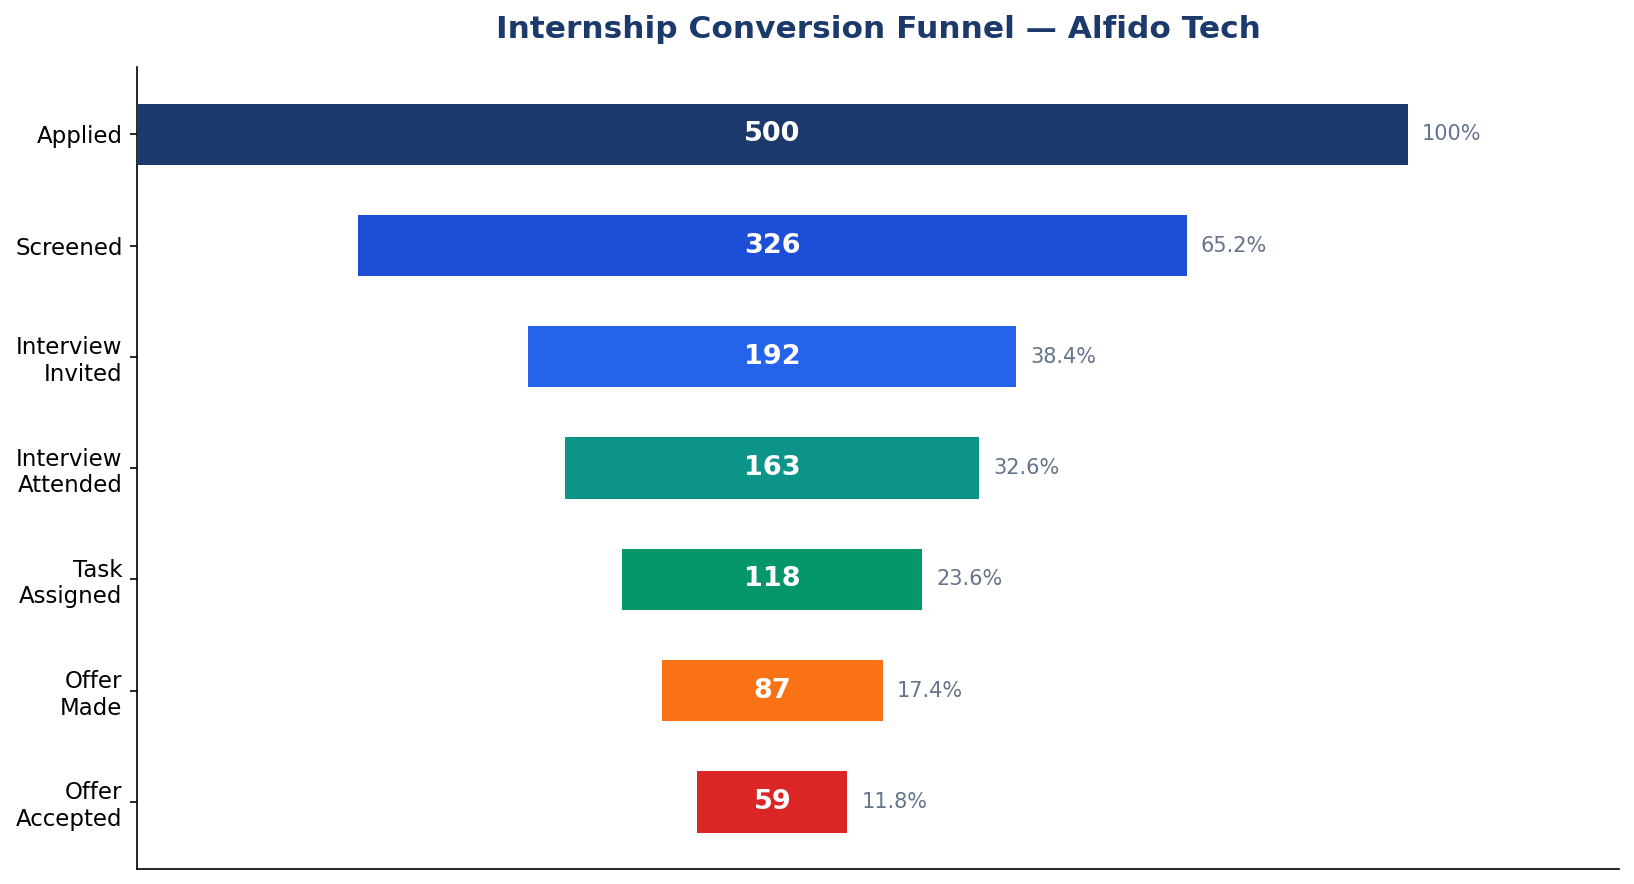

In [ ]:
Image(os.path.join(CHARTS_DIR, '01_funnel.png'))


## 4. Stage-wise Drop-off Analysis

In [7]:
pairs = [('Applied','Screened',500,326),('Screened','Interview Invited',326,192),
         ('Interview Invited','Attended',192,163),('Attended','Task Assigned',163,118),
         ('Task Assigned','Offer Made',118,87),('Offer Made','Accepted',87,59)]
drop_df = pd.DataFrame([(a,b,n,m,round((n-m)/n*100,1)) for a,b,n,m in pairs],
                        columns=['From','To','Count In','Count Out','Drop-off %'])
print(drop_df.to_string(index=False))
print(f"\n⚠ Highest drop: Applied→Screened ({drop_df['Drop-off %'].max()}%)")


             From                To  Count In  Count Out  Drop-off %
          Applied          Screened       500        326        34.8
         Screened Interview Invited       326        192        41.1
Interview Invited          Attended       192        163        15.1
         Attended     Task Assigned       163        118        27.6
    Task Assigned        Offer Made       118         87        26.3
       Offer Made          Accepted        87         59        32.2

⚠ Highest drop: Applied→Screened (41.1%)


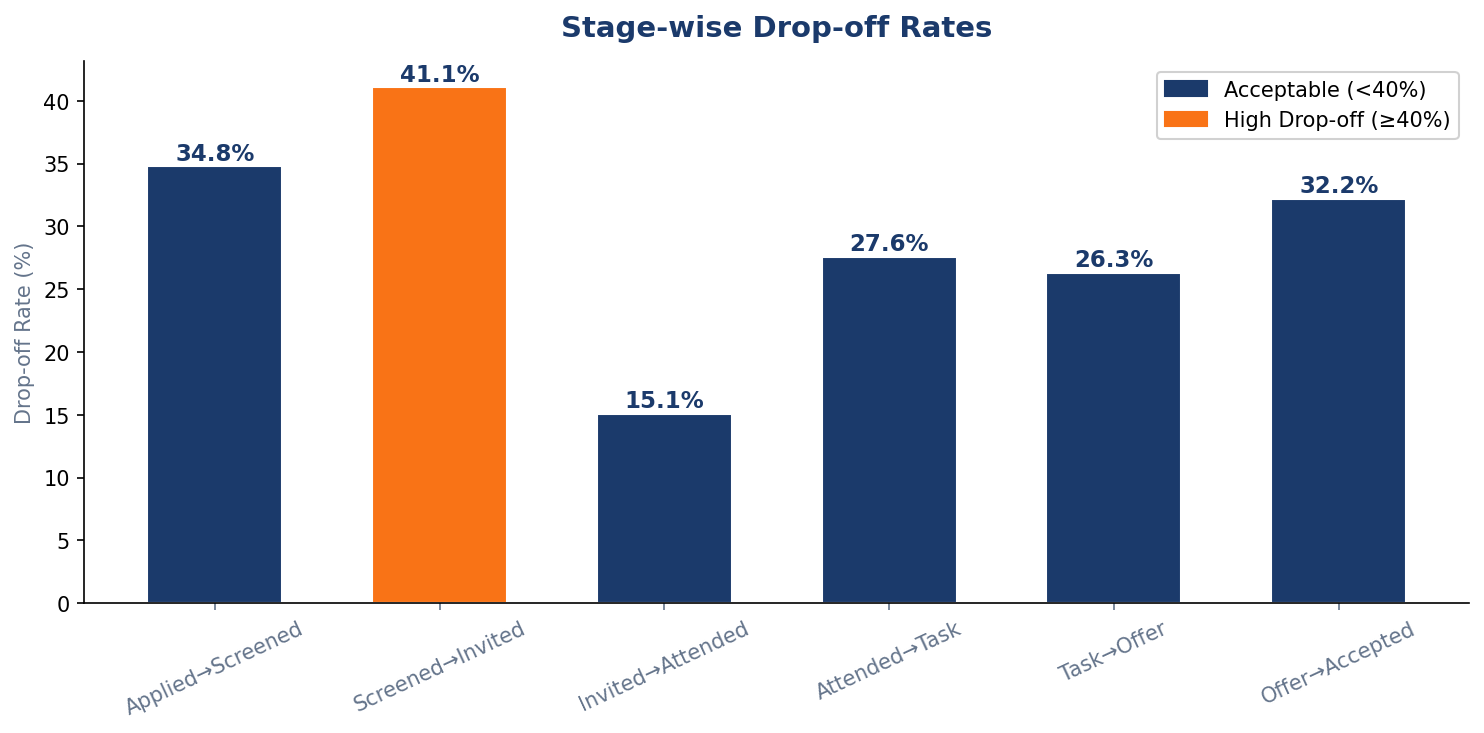

In [ ]:
Image(os.path.join(CHARTS_DIR, '06_dropoff.png'))


## 5. Department-wise Conversion

In [8]:
dept_stats = df.groupby('department').agg(
    Applied=('applicant_id','count'),
    Screened=('screened','sum'),
    Offers_Made=('offer_made','sum'),
    Accepted=('offer_accepted','sum')
).reset_index()
dept_stats['Screen_Rate%'] = (dept_stats['Screened']/dept_stats['Applied']*100).round(1)
dept_stats['Conv_Rate%']   = (dept_stats['Accepted']/dept_stats['Applied']*100).round(1)
dept_stats = dept_stats.sort_values('Conv_Rate%', ascending=False)
print(dept_stats.to_string(index=False))


          department  Applied  Screened  Offers_Made  Accepted  Screen_Rate%  Conv_Rate%
Business Development       55        40           12         7          72.7        12.7
        Data Science      165       111           27        21          67.3        12.7
     Web Development      122        73           19        15          59.8        12.3
   Digital Marketing       89        60           18        10          67.4        11.2
        UI/UX Design       69        42           11         6          60.9         8.7


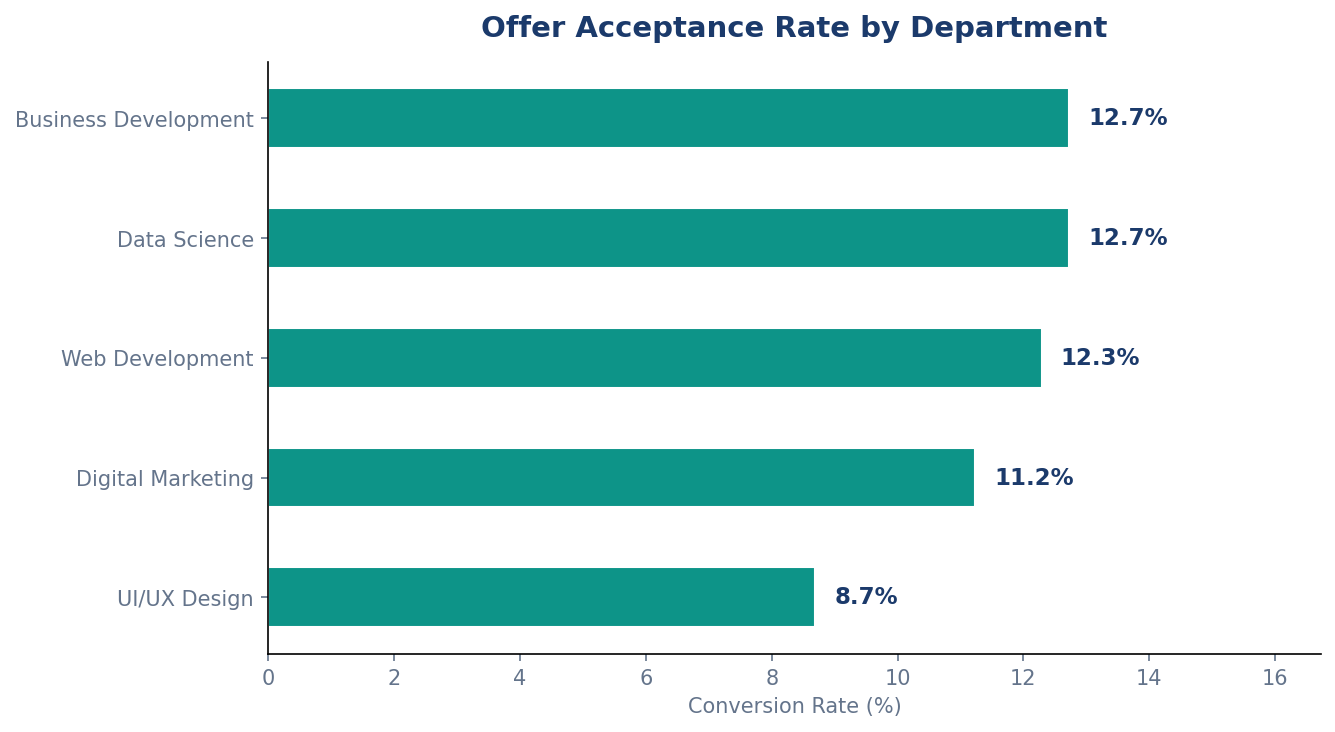

In [ ]:
Image(os.path.join(CHARTS_DIR, '02_dept_conversion.png'))


## 6. Recruitment Source Effectiveness

In [9]:
src_stats = df.groupby('source').agg(
    Applied=('applicant_id','count'),
    Accepted=('offer_accepted','sum')
).reset_index()
src_stats['Conv_Rate%']   = (src_stats['Accepted']/src_stats['Applied']*100).round(1)
src_stats['Efficiency']   = src_stats['Conv_Rate%'].apply(
    lambda x: 'High' if x > 14 else ('Medium' if x > 10 else 'Low'))
print(src_stats.sort_values('Conv_Rate%', ascending=False).to_string(index=False))


         source  Applied  Accepted  Conv_Rate% Efficiency
         Naukri       59        12        20.3       High
       Referral       65        11        16.9       High
 College Portal      106        15        14.2       High
Company Website       71         7         9.9        Low
       LinkedIn      168        13         7.7        Low
      Instagram       31         1         3.2        Low


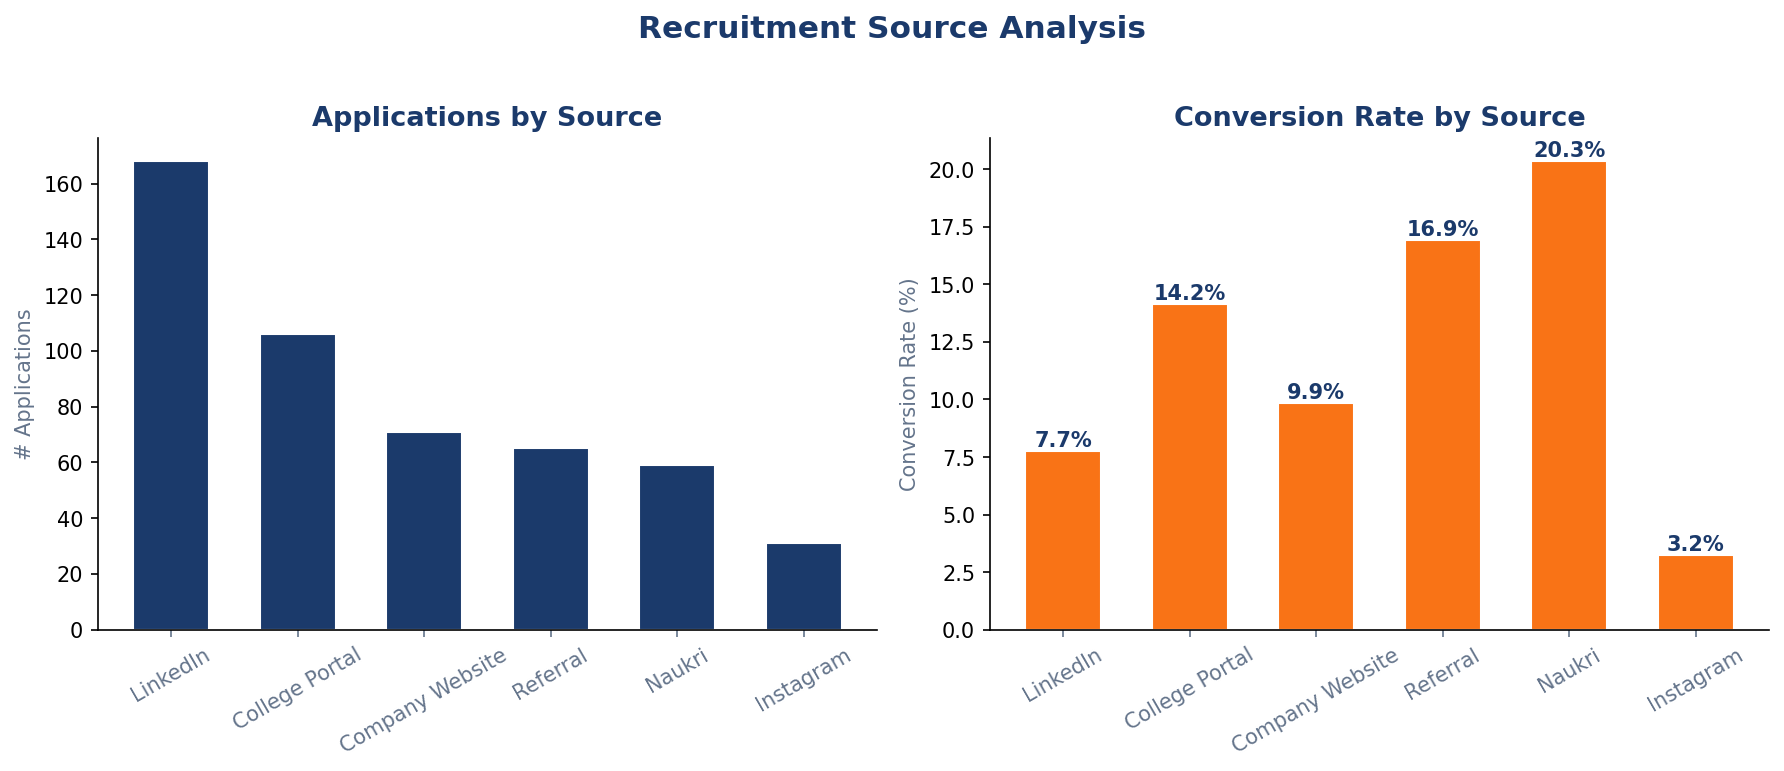

In [ ]:
Image(os.path.join(CHARTS_DIR, '03_source.png'))


## 7. Monthly Trend Analysis

In [10]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('application_month').agg(
    Applications=('applicant_id','count'),
    Accepted=('offer_accepted','sum')
).reindex(month_order).fillna(0).reset_index()
monthly.columns = ['Month','Applications','Accepted']
monthly['Conv_Rate%'] = (monthly['Accepted']/monthly['Applications']*100).round(1)
print(monthly.to_string(index=False))


Month  Applications  Accepted  Conv_Rate%
  Jan            23         2         8.7
  Feb            25         3        12.0
  Mar            37         5        13.5
  Apr            31         4        12.9
  May            48         6        12.5
  Jun            56         4         7.1
  Jul            59        10        16.9
  Aug            60         5         8.3
  Sep            50         4         8.0
  Oct            42         8        19.0
  Nov            39         3         7.7
  Dec            30         5        16.7


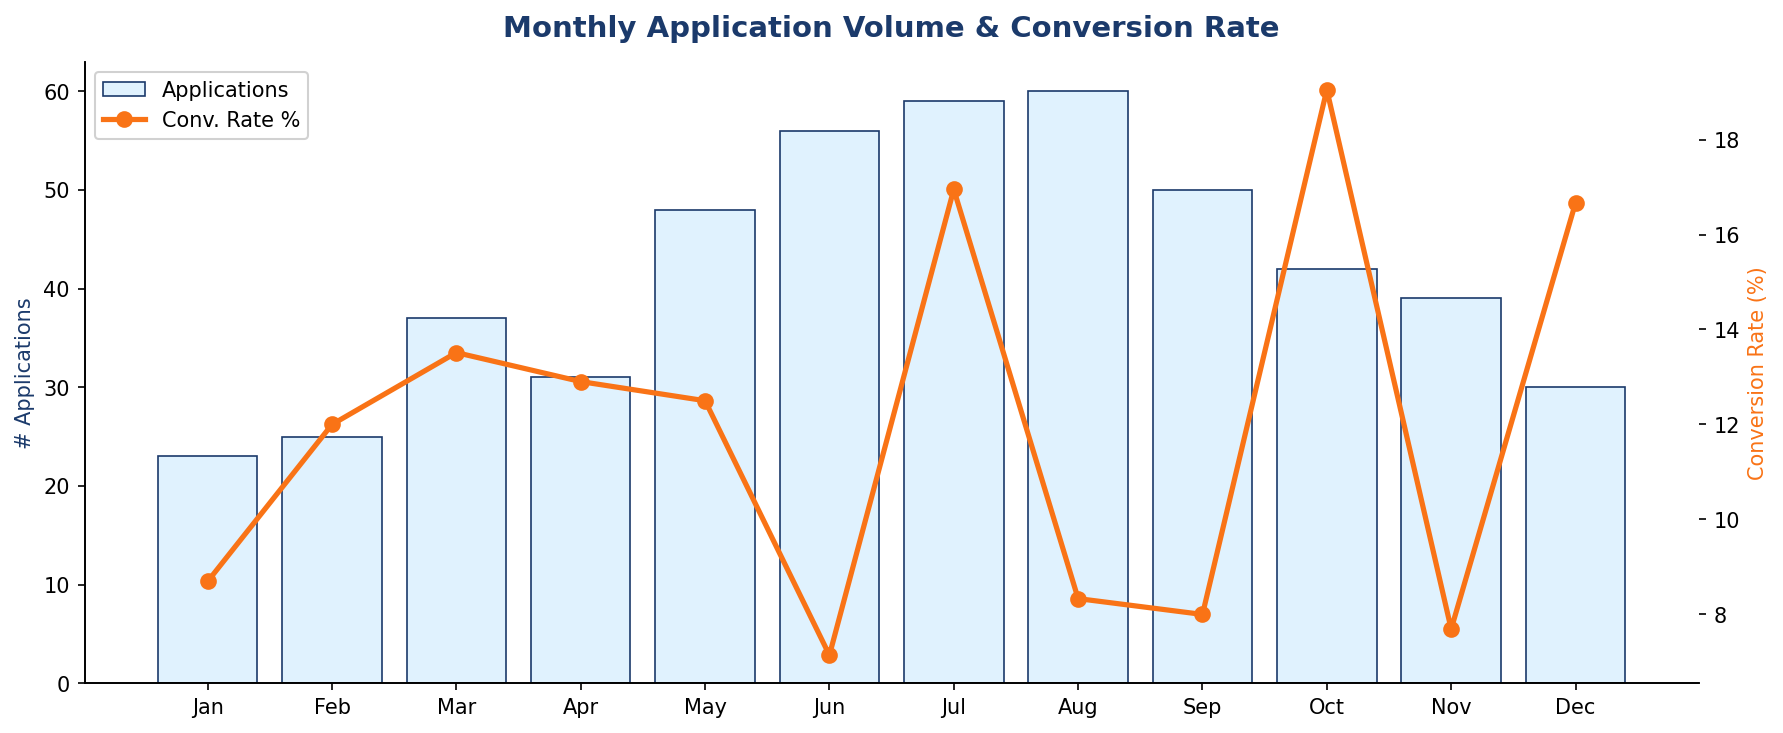

In [ ]:
Image(os.path.join(CHARTS_DIR, '04_monthly_trend.png'))


## 8. Academic Performance & Conversion

In [11]:
df['cgpa_band'] = pd.cut(df['cgpa'], bins=[5,6,7,8,9,10],
                          labels=['5-6','6-7','7-8','8-9','9-10'])
band_stats = df.groupby('cgpa_band', observed=True).agg(
    Count=('applicant_id','count'),
    Accepted=('offer_accepted','sum')
).reset_index()
band_stats['Conv_Rate%'] = (band_stats['Accepted']/band_stats['Count']*100).round(1)
print(band_stats.to_string(index=False))


cgpa_band  Count  Accepted  Conv_Rate%
      5-6     21         2         9.5
      6-7    111         5         4.5
      7-8    226        33        14.6
      8-9    118        16        13.6
     9-10     21         3        14.3


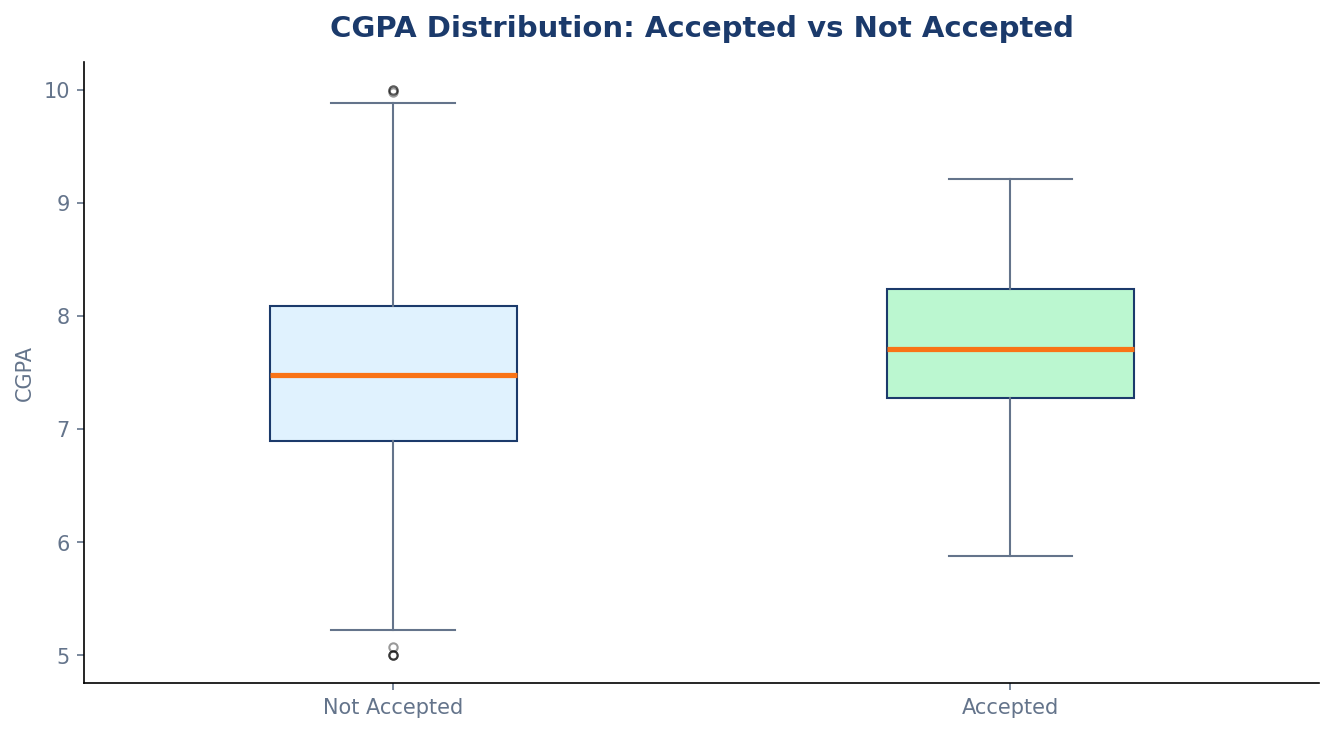

In [ ]:
Image(os.path.join(CHARTS_DIR, '05_cgpa_boxplot.png'))


## 9. Key Insights & Recommendations

### 📊 Funnel Summary
- **500 applicants → 59 conversions** = **11.8% overall conversion rate**
- Biggest drop at **Applied → Screened** (34.8% lost)

### 🏆 Top Insights
1. **Data Science & Web Dev** have the highest acceptance rates
2. **Referral & College Portal** sources produce the best conversion rates
3. **CGPA > 7.5 candidates** are ~2× more likely to accept offers
4. **June–August** is peak application season

### ✅ Recommendations
| Priority | Action | Expected Impact |
|----------|--------|----------------|
| High | Automated pre-screening form | +15% screen rate |
| High | Double down on College Portal & Referral | +8% conversion |
| Medium | Incentives for Data Science & UI/UX roles | +5% acceptance |
| Medium | WhatsApp + email interview reminders | +3% attendance |
| Low | CGPA-weighted shortlisting (>7.5) | Higher quality hires |
